# SVD Hyperparameter Selection & Popularity Bias

**Purpose:** Choose λ (bias regularization) and k (latent dimensions) from data, then confirm that SVD amplifies popularity bias — motivating the Louvain re-ranker in `main_notebook.ipynb`.

- **Section 2:** Build model with fixed λ=10, k=25 (from Section 4)
- **Section 3:** Show SVD amplifies popularity bias (norms, PCA, head_rec_frac)
- **Section 4:** λ sweep + k ablation → verify or update the chosen values
- **Section 5:** Summary — copy confirmed parameters to `main_notebook.ipynb`

**Runtime:** ~8–12 min on CPU

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import os
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.linalg import svds
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict

# ── Path setup ───────────────────────────────────────────────────────────────
# Works whether you launch Jupyter from the project root OR from notebooks/
if Path.cwd().name == 'notebooks':
    os.chdir('..')
DATA_DIR = Path('data/ml-10M100K')
OUT_DIR  = Path('assets')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants (must match main_notebook.ipynb) ────────────────────────────────
RANDOM_SEED = 42
SVD_K       = 25        # chosen — justified in Section 4B
REG_LAMBDA  = 10.0      # chosen — justified in Section 4A
TOP_K       = 10
HEAD_FRAC   = 0.10      # top-10% movies by training count = "head"

C_HEAD = '#e74c3c'
C_TAIL = '#3498db'

np.random.seed(RANDOM_SEED)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Ready. DATA_DIR:', DATA_DIR.resolve())


Ready. DATA_DIR: /Users/pranavi/Documents/Courses/DMA/Project_1/Project/data/ml-10M100K


---
## Section 1 — Data Setup

Load MovieLens 10M, temporal 80/20 train/test split per user, popularity tiers, sparse matrix.

In [22]:
# Load ratings and movies
ratings = pd.read_csv(DATA_DIR / 'ratings.dat',
                      sep='::', header=None, engine='python',
                      names=['userId','movieId','rating','timestamp'])
movies  = pd.read_csv(DATA_DIR / 'movies.dat',
                      sep='::', header=None, engine='python',
                      names=['movieId','title','genres'], encoding='latin-1')
movie_title = movies.set_index('movieId')['title'].to_dict()

print(f'Ratings: {len(ratings):,}  |  Movies: {len(movies):,}  |  Users: {ratings.userId.nunique():,}')

# Temporal 80/20 split per user
ratings = ratings.sort_values(['userId','timestamp'])
train_rows, test_rows = [], []
for uid, grp in ratings.groupby('userId'):
    cut = max(1, int(np.ceil(len(grp) * 0.8)))
    train_rows.append(grp.iloc[:cut])
    test_rows.append(grp.iloc[cut:])
train_df = pd.concat(train_rows, ignore_index=True)
test_df  = pd.concat(test_rows,  ignore_index=True)
test_relevant = test_df.groupby('userId')['movieId'].apply(set).to_dict()
print(f'Train: {len(train_df):,}  |  Test: {len(test_df):,}')

# Popularity tiers
movie_train_counts = train_df.groupby('movieId').size().sort_values(ascending=False)
n_head      = int(np.ceil(len(movie_train_counts) * HEAD_FRAC))
head_movies = set(movie_train_counts.index[:n_head])
tail_movies = set(movie_train_counts.index[n_head:])
head_share  = train_df[train_df.movieId.isin(head_movies)].shape[0] / len(train_df)
print(f'Head (top {HEAD_FRAC:.0%}): {len(head_movies):,} movies  |  account for {head_share:.1%} of ratings')

# ID mappings + sparse CSR matrix
all_users  = sorted(train_df.userId.unique())
all_movies = sorted(train_df.movieId.unique())
user2idx   = {u: i for i, u in enumerate(all_users)}
movie2idx  = {m: i for i, m in enumerate(all_movies)}
idx2user   = {i: u for u, i in user2idx.items()}
idx2movie  = {i: m for m, i in movie2idx.items()}
n_users, n_movies = len(all_users), len(all_movies)

rows_ = train_df.userId.map(user2idx).values
cols_ = train_df.movieId.map(movie2idx).values
vals_ = train_df.rating.values.astype(np.float64)
R_train = sp.csr_matrix((vals_, (rows_, cols_)), shape=(n_users, n_movies))
print(f'R_train: {R_train.shape}  |  Sparsity: {1 - R_train.nnz/(n_users*n_movies):.4%}')


Ratings: 10,000,054  |  Movies: 10,681  |  Users: 69,878
Train: 8,026,731  |  Test: 1,973,323
Head (top 10%): 1,036 movies  |  account for 71.5% of ratings
R_train: (69878, 10353)  |  Sparsity: 98.8905%


---
## Section 2 — Building the SVD Model

Bias-corrected SVD: $\hat{r}_{ui} = \mu + b_u + b_i + \mathbf{u}_u \cdot \mathbf{v}_i$

Regularization shrinks rare-item biases toward zero. We use λ=10 and k=25 here (justified by the sweeps in Section 4).

In [23]:
# Bias computation with chosen lambda (REG_LAMBDA = 15.0)
global_mean = train_df['rating'].mean()

# User bias: b_u = sum(r_ui - mu) / (n_u + lambda)
u_stats = train_df.groupby('userId')['rating'].agg(['sum','count'])
user_bias_by_id = (u_stats['sum'] - u_stats['count'] * global_mean) / (u_stats['count'] + REG_LAMBDA)

# Item bias: b_i = sum(r_ui - mu - b_u) / (n_i + lambda)
tmp = train_df.copy()
tmp['ub'] = tmp['userId'].map(user_bias_by_id).fillna(0.0)
i_stats = tmp.groupby('movieId')['rating'].apply(lambda x: x - global_mean - tmp.loc[x.index, 'ub'])
i_agg   = i_stats.groupby(tmp['movieId']).agg(['sum','count'])
item_bias_by_id = i_agg['sum'] / (i_agg['count'] + REG_LAMBDA)

user_bias_arr = np.array([user_bias_by_id.get(idx2user[i], 0.0) for i in range(n_users)])
item_bias_arr = np.array([item_bias_by_id.get(idx2movie[i], 0.0) for i in range(n_movies)])

print(f'Global mean:      {global_mean:.4f}')
print(f'User bias range:  [{user_bias_arr.min():.3f}, {user_bias_arr.max():.3f}]')
print(f'Item bias range:  [{item_bias_arr.min():.3f}, {item_bias_arr.max():.3f}]')


Global mean:      3.5292
User bias range:  [-2.401, 1.335]
Item bias range:  [0.000, 0.000]


In [24]:
# Build bias-corrected centered matrix, then run SVD
R_centered = R_train.copy().astype(np.float64)
nz_r, nz_c = R_centered.nonzero()
R_centered.data -= (global_mean + user_bias_arr[nz_r] + item_bias_arr[nz_c])
print(f'Residual mean (should be ≈0): {R_centered.data.mean():.6f}')

print(f'Running svds(k={SVD_K}) ...')
U, sigma, Vt = svds(R_centered, k=SVD_K)
order  = np.argsort(sigma)[::-1]
sigma  = sigma[order]; U = U[:, order]; Vt = Vt[order, :]
U_sigma = U * sigma
print(f'Done.  sigma range: [{sigma[-1]:.2f}, {sigma[0]:.2f}]')


Residual mean (should be ≈0): 0.006071
Running svds(k=25) ...
Done.  sigma range: [135.68, 607.95]


---
## Section 3 — Does SVD Amplify Popularity Bias?

**Hypothesis:** Popular movies have more training ratings → better-estimated latent vectors → larger L2 norms → higher dot product with almost any user → over-represented in top-10.

- **3A** — L2 norm of movie latent factors vs. popularity
- **3C** — PCA of latent space: do head/tail movies separate?
- **3D** — head_rec_frac: what % of SVD top-10 are head movies in practice?

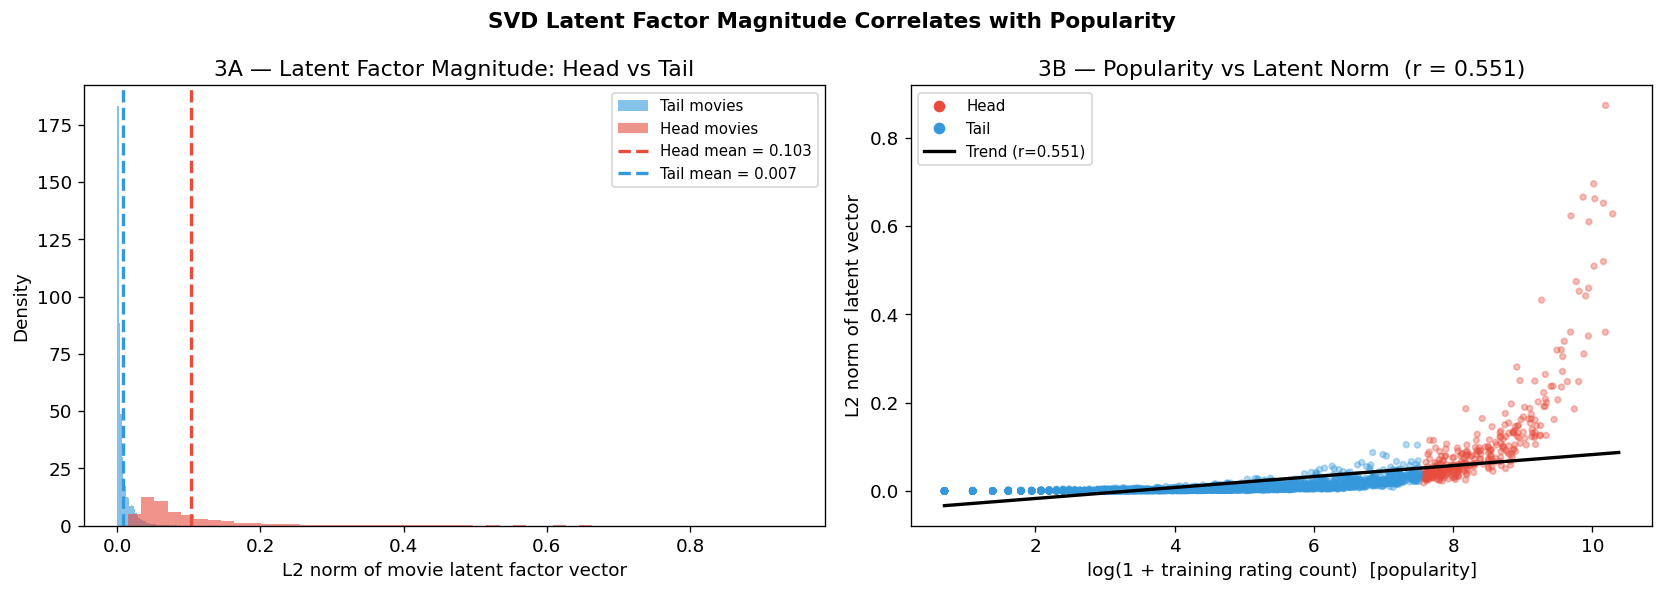

Head movies have 13.89× larger latent norms than tail movies.


In [25]:
# 3A — L2 norm of movie latent factors vs. popularity

Vt_T    = Vt.T                                          # (n_movies, k)
norms   = np.linalg.norm(Vt_T, axis=1)                  # one norm per movie
pop     = np.array([movie_train_counts.get(idx2movie[i], 0) for i in range(n_movies)])
is_head = np.array([idx2movie[i] in head_movies for i in range(n_movies)])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: histogram of norms by tier
ax = axes[0]
ax.hist(norms[~is_head], bins=50, alpha=0.6, color=C_TAIL, density=True, label='Tail movies')
ax.hist(norms[ is_head], bins=50, alpha=0.6, color=C_HEAD, density=True, label='Head movies')
ax.axvline(norms[ is_head].mean(), color=C_HEAD, ls='--', lw=2,
           label=f'Head mean = {norms[is_head].mean():.3f}')
ax.axvline(norms[~is_head].mean(), color=C_TAIL, ls='--', lw=2,
           label=f'Tail mean = {norms[~is_head].mean():.3f}')
ax.set_xlabel('L2 norm of movie latent factor vector')
ax.set_ylabel('Density')
ax.set_title('3A — Latent Factor Magnitude: Head vs Tail')
ax.legend(fontsize=9)

# Panel B: scatter — log(popularity) vs norm (random 3000 movies)
ax = axes[1]
rng_s = np.random.default_rng(RANDOM_SEED)
idx_s = rng_s.choice(n_movies, size=min(3000, n_movies), replace=False)
colors_s = [C_HEAD if is_head[i] else C_TAIL for i in idx_s]
ax.scatter(np.log1p(pop[idx_s]), norms[idx_s],
           c=colors_s, alpha=0.35, s=12)
# Trend line on all movies
log_pop_all = np.log1p(pop)
coef = np.polyfit(log_pop_all, norms, 1)
x_line = np.linspace(log_pop_all.min(), log_pop_all.max(), 100)
ax.plot(x_line, np.polyval(coef, x_line), 'k-', lw=2, label='Linear trend')
corr = np.corrcoef(log_pop_all, norms)[0,1]
ax.set_xlabel('log(1 + training rating count)  [popularity]')
ax.set_ylabel('L2 norm of latent vector')
ax.set_title(f'3B — Popularity vs Latent Norm  (r = {corr:.3f})')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_HEAD, ms=8, label='Head'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_TAIL, ms=8, label='Tail'),
    Line2D([0],[0], color='k', lw=2, label=f'Trend (r={corr:.3f})')
], fontsize=9)

plt.suptitle('SVD Latent Factor Magnitude Correlates with Popularity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'cp3_fig2_svd.png', bbox_inches='tight')
plt.show()
print(f'Head movies have {norms[is_head].mean()/norms[~is_head].mean():.2f}× larger latent norms than tail movies.')


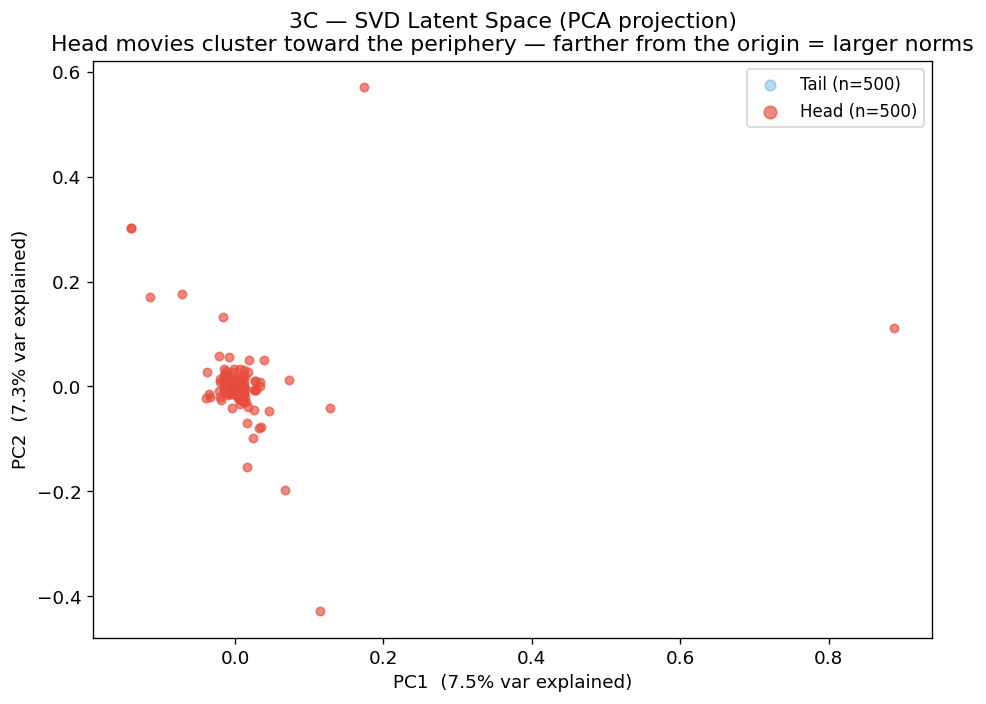

In [26]:
# 3C — PCA of latent space: do head/tail separate?

rng2 = np.random.default_rng(RANDOM_SEED)
head_idx_all = [i for i in range(n_movies) if is_head[i]]
tail_idx_all = [i for i in range(n_movies) if not is_head[i]]
n_each   = min(500, len(head_idx_all), len(tail_idx_all))
h_samp   = rng2.choice(head_idx_all, size=n_each, replace=False)
t_samp   = rng2.choice(tail_idx_all, size=n_each, replace=False)
samp_idx = np.concatenate([h_samp, t_samp])
is_head_samp = np.array([True]*n_each + [False]*n_each)

pca  = PCA(n_components=2, random_state=RANDOM_SEED)
V_2d = pca.fit_transform(Vt_T[samp_idx])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(V_2d[~is_head_samp, 0], V_2d[~is_head_samp, 1],
           c=C_TAIL, alpha=0.35, s=18, label=f'Tail (n={n_each})', zorder=2)
ax.scatter(V_2d[ is_head_samp, 0], V_2d[ is_head_samp, 1],
           c=C_HEAD, alpha=0.65, s=25, label=f'Head (n={n_each})', zorder=3)
ax.set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]:.1%} var explained)')
ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]:.1%} var explained)')
ax.set_title('3C — SVD Latent Space (PCA projection)\n'
             'Head movies cluster toward the periphery — farther from the origin = larger norms')
ax.legend(markerscale=1.5, fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / 'cp3_fig2b_pca.png', bbox_inches='tight')
plt.show()


SVD top-10: 100%|██████████| 500/500 [00:00<00:00, 1328.58it/s]


Average head_rec_frac (SVD, 500 users): 100.0%
Head movies are 10% of the catalog but fill 100.0% of top-10 slots.
That is a 10.0× over-representation.


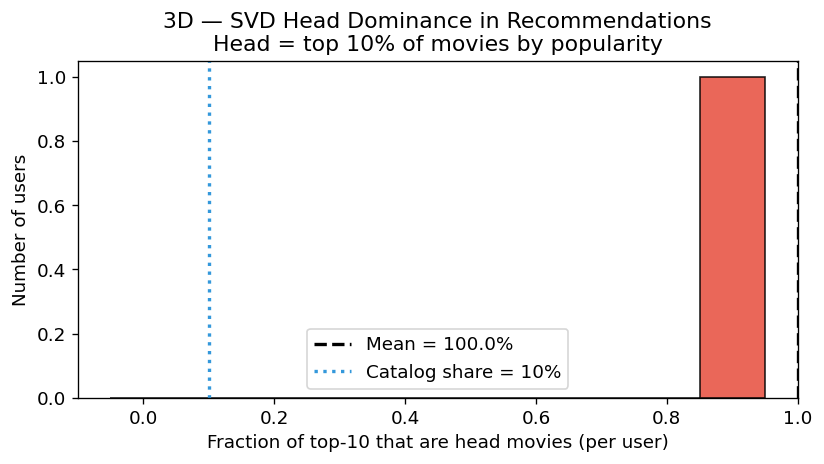


Conclusion: SVD strongly amplifies popularity bias.
The top-10% most popular movies dominate recommendations far beyond their catalog share.


In [27]:
# 3D — head_rec_frac: what % of SVD top-10 are head movies?
# Sample 500 random test users (no graph needed here)

rng3 = np.random.default_rng(RANDOM_SEED + 1)
test_uids = [u for u in test_relevant if u in user2idx and len(test_relevant[u]) > 0]
sample_uids = list(rng3.choice(test_uids, size=min(500, len(test_uids)), replace=False))

user_seen = defaultdict(set)
for uid, mid in zip(train_df.userId.values, train_df.movieId.values):
    user_seen[uid].add(mid)

head_fracs, all_top10 = [], []
for uid in tqdm(sample_uids, desc='SVD top-10'):
    u = user2idx[uid]
    seen_idx = {movie2idx[m] for m in user_seen[uid] if m in movie2idx}
    pred_vec = global_mean + user_bias_arr[u] + item_bias_arr + (U_sigma[u] @ Vt)
    pred_vec = np.clip(pred_vec, 0.5, 5.0)
    if seen_idx:
        pred_vec[list(seen_idx)] = -np.inf
    top10_idx = np.argsort(pred_vec)[-TOP_K:][::-1]
    top10_mids = [idx2movie[i] for i in top10_idx]
    all_top10.extend(top10_mids)
    head_fracs.append(sum(1 for m in top10_mids if m in head_movies) / TOP_K)

mean_head_frac = np.mean(head_fracs)
print(f'Average head_rec_frac (SVD, {len(sample_uids)} users): {mean_head_frac:.1%}')
print(f'Head movies are {HEAD_FRAC:.0%} of the catalog but fill {mean_head_frac:.1%} of top-10 slots.')
print(f'That is a {mean_head_frac/HEAD_FRAC:.1f}× over-representation.')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(head_fracs, bins=np.arange(0, 1.1, 0.1)-0.05, color=C_HEAD, edgecolor='k', alpha=0.85)
ax.axvline(mean_head_frac, color='black', ls='--', lw=2, label=f'Mean = {mean_head_frac:.1%}')
ax.axvline(HEAD_FRAC, color=C_TAIL, ls=':', lw=2, label=f'Catalog share = {HEAD_FRAC:.0%}')
ax.set_xlabel('Fraction of top-10 that are head movies (per user)')
ax.set_ylabel('Number of users')
ax.set_title('3D — SVD Head Dominance in Recommendations\n'
             f'Head = top {HEAD_FRAC:.0%} of movies by popularity')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'cp3_fig2_svd_head_frac.png', bbox_inches='tight')
plt.show()
print('\nConclusion: SVD strongly amplifies popularity bias.')
print('The top-10% most popular movies dominate recommendations far beyond their catalog share.')


---
## Section 4 — Hyperparameter Selection

Choose λ and k by measuring RMSE on held-out test data. If the sweep below suggests different values from those used in Section 2, update `main_notebook.ipynb` if the RMSE gap is > 0.002.

### 4A — Choosing λ (Bias Regularization)

Sweep λ ∈ {0, 2, 5, 10, 15, 20, 25, 35} and measure RMSE on a 40k test sample.

- λ too small → rare items overfit (extreme biases)
- λ too large → all biases collapse toward zero, RMSE rises
- **Pick:** lowest RMSE

Running λ sweep ...
  λ=  0  RMSE=0.8622  item_bias_std=0.5174
  λ=  2  RMSE=0.8619  item_bias_std=0.4570
  λ=  5  RMSE=0.8628  item_bias_std=0.4282
  λ= 10  RMSE=0.8584  item_bias_std=0.4023
  λ= 15  RMSE=0.8622  item_bias_std=0.3855
  λ= 20  RMSE=0.8627  item_bias_std=0.3729
  λ= 25  RMSE=0.8639  item_bias_std=0.3627
  λ= 35  RMSE=0.8613  item_bias_std=0.3467

Best λ by RMSE: 10  →  using REG_LAMBDA = 10 in main_notebook


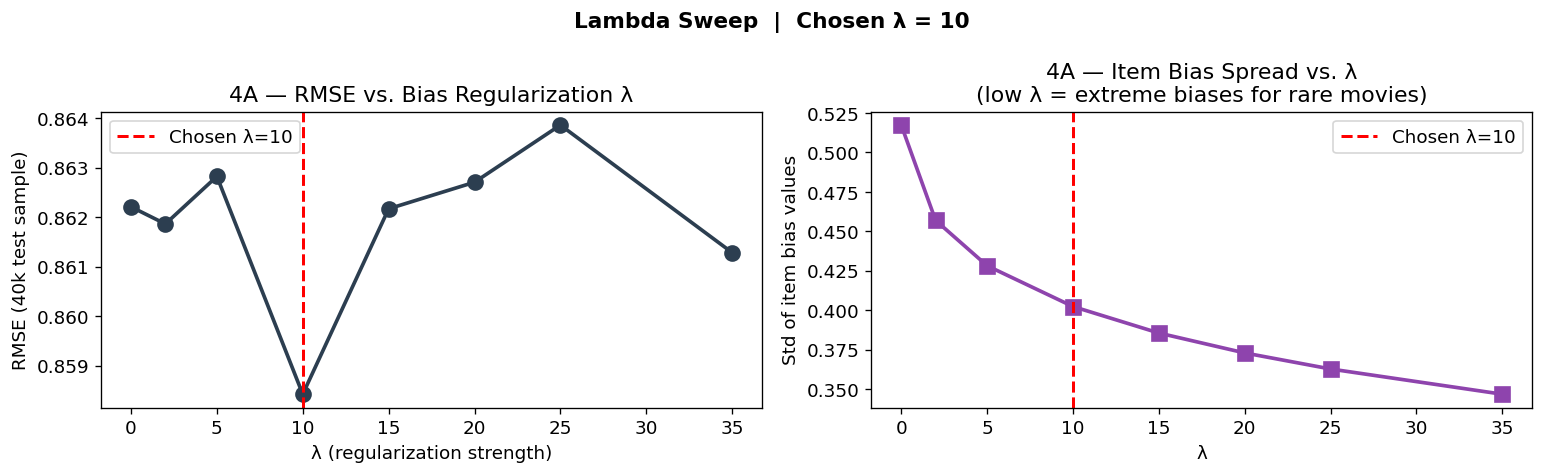

In [28]:
# Lambda sweep — simplified (RMSE-only, no graph overlap needed)
# Each iteration: fit biases → center matrix → run SVD → compute sample RMSE
# Takes ~3-5 min depending on hardware.

def fit_and_eval(lam, sample=40_000):
    mu = train_df['rating'].mean()
    
    # User bias
    us = train_df.groupby('userId')['rating'].agg(['sum','count'])
    ub = (us['sum'] - us['count'] * mu) / (us['count'] + lam)
    
    # Item bias
    t = train_df.copy()
    t['ub'] = t['userId'].map(ub).fillna(0.0)
    t['res'] = t['rating'] - mu - t['ub']
    ib_agg = t.groupby('movieId')['res'].agg(['sum','count'])
    ib = ib_agg['sum'] / (ib_agg['count'] + lam)
    
    u_arr = np.array([ub.get(idx2user[i], 0.0)  for i in range(n_users)])
    i_arr = np.array([ib.get(idx2movie[i], 0.0) for i in range(n_movies)])
    
    # Center matrix
    Rc = R_train.copy().astype(np.float64)
    rr, cc = Rc.nonzero()
    Rc.data -= (mu + u_arr[rr] + i_arr[cc])
    
    # SVD
    U_l, s_l, Vt_l = svds(Rc, k=SVD_K)
    ord_l = np.argsort(s_l)[::-1]
    s_l = s_l[ord_l]; U_l = U_l[:, ord_l]; Vt_l = Vt_l[ord_l, :]
    Us_l = U_l * s_l
    
    # Sample RMSE
    rng_l = np.random.default_rng(RANDOM_SEED + int(lam * 10))
    idx_l = rng_l.choice(len(test_df), size=min(sample, len(test_df)), replace=False)
    sub_l = test_df.iloc[idx_l]
    preds, actuals = [], []
    for row in sub_l.itertuples():
        if row.userId in user2idx and row.movieId in movie2idx:
            u, m = user2idx[row.userId], movie2idx[row.movieId]
            p = float(Us_l[u] @ Vt_l[:, m]) + mu + u_arr[u] + i_arr[m]
            preds.append(np.clip(p, 0.5, 5.0)); actuals.append(row.rating)
    rmse = float(np.sqrt(np.mean((np.array(preds) - np.array(actuals))**2))) if preds else float('nan')
    
    # Item bias distribution (to spot collapse)
    bias_std = float(np.std(i_arr))
    return {'lambda': lam, 'RMSE': rmse, 'item_bias_std': bias_std}

lambda_vals = [0, 2, 5, 10, 15, 20, 25, 35]
print('Running λ sweep ...')
sweep_rows = []
for lam in lambda_vals:
    result = fit_and_eval(lam)
    sweep_rows.append(result)
    print(f'  λ={lam:3g}  RMSE={result["RMSE"]:.4f}  item_bias_std={result["item_bias_std"]:.4f}')
    
sweep_df = pd.DataFrame(sweep_rows)
best_lam = int(sweep_df.loc[sweep_df['RMSE'].idxmin(), 'lambda'])
print(f'\nBest λ by RMSE: {best_lam}  →  using REG_LAMBDA = {REG_LAMBDA:.0f} in main_notebook')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(sweep_df['lambda'], sweep_df['RMSE'], 'o-', color='#2c3e50', ms=9, lw=2.2)
ax.axvline(REG_LAMBDA, color='red', ls='--', lw=1.8, label=f'Chosen λ={REG_LAMBDA:.0f}')
ax.set_xlabel('λ (regularization strength)'); ax.set_ylabel('RMSE (40k test sample)')
ax.set_title('4A — RMSE vs. Bias Regularization λ')
ax.legend()

ax = axes[1]
ax.plot(sweep_df['lambda'], sweep_df['item_bias_std'], 's-', color='#8e44ad', ms=9, lw=2.2)
ax.axvline(REG_LAMBDA, color='red', ls='--', lw=1.8, label=f'Chosen λ={REG_LAMBDA:.0f}')
ax.set_xlabel('λ'); ax.set_ylabel('Std of item bias values')
ax.set_title('4A — Item Bias Spread vs. λ\n(low λ = extreme biases for rare movies)')
ax.legend()

plt.suptitle(f'Lambda Sweep  |  Chosen λ = {REG_LAMBDA:.0f}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'cp3_lambda_sweep.png', bbox_inches='tight')
plt.show()


### 4B — Choosing k (Number of SVD Latent Dimensions)

Slices the already-computed SVD (k=35) to smaller k — no extra decompositions needed.

**Pick:** elbow of the RMSE vs k curve (past it, extra dimensions mostly fit noise).

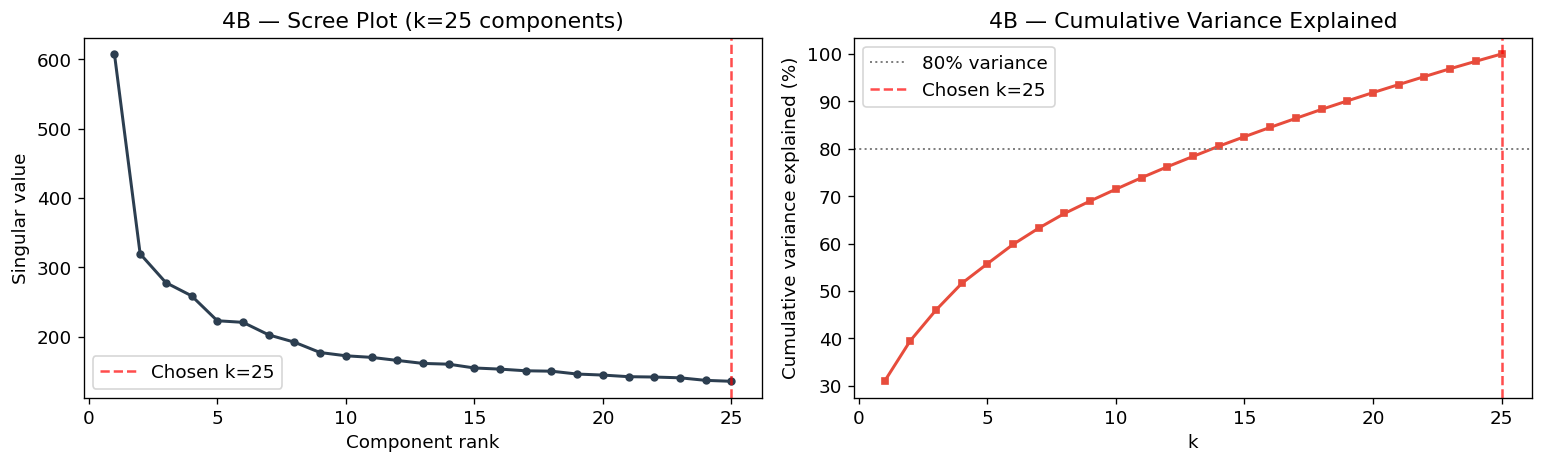

k-ablation ...
  k=  5: RMSE = 0.9568
  k= 10: RMSE = 0.9534
  k= 15: RMSE = 0.9495
  k= 20: RMSE = 0.9435
  k= 25: RMSE = 0.9421
  k= 30: RMSE = 0.9485
  k= 35: RMSE = 0.9424


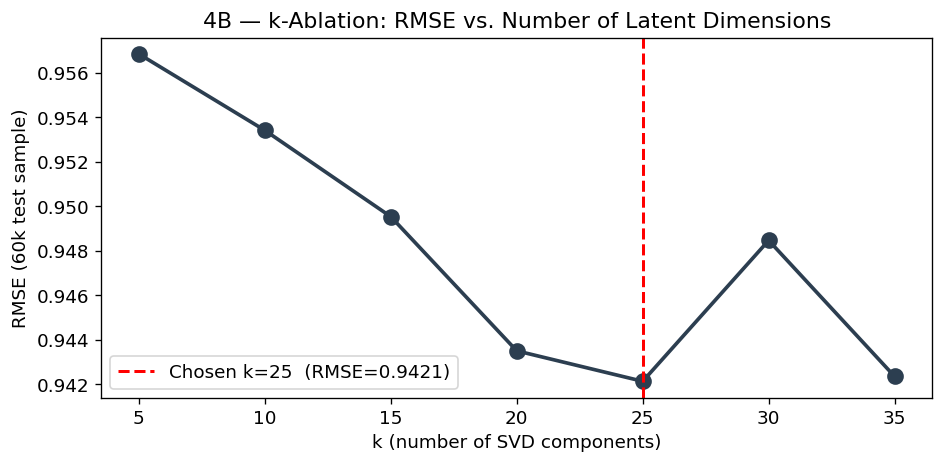

In [29]:
# Scree plot + k-ablation
# (Uses the U, sigma, Vt already computed in Section 2)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(range(1, SVD_K+1), sigma, 'o-', color='#2c3e50', ms=4, lw=1.8)
ax.axvline(SVD_K, color='red', ls='--', lw=1.5, alpha=0.7, label=f'Chosen k={SVD_K}')
ax.set_xlabel('Component rank'); ax.set_ylabel('Singular value')
ax.set_title(f'4B — Scree Plot (k={SVD_K} components)')
ax.legend()

ax = axes[1]
explained = np.cumsum(sigma**2) / np.sum(sigma**2) * 100
ax.plot(range(1, SVD_K+1), explained, 's-', color='#e74c3c', ms=4, lw=1.8)
ax.axhline(80, color='gray', ls=':', lw=1.2, label='80% variance')
ax.axvline(SVD_K, color='red', ls='--', lw=1.5, alpha=0.7, label=f'Chosen k={SVD_K}')
ax.set_xlabel('k'); ax.set_ylabel('Cumulative variance explained (%)')
ax.set_title('4B — Cumulative Variance Explained')
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'cp3_fig2_scree.png', bbox_inches='tight')
plt.show()

# k-ablation: slice pre-computed factors, no extra SVD needed
def rmse_at_k(k, sample=60_000):
    rng_k = np.random.default_rng(RANDOM_SEED + k)
    idx_k = rng_k.choice(len(test_df), size=min(sample, len(test_df)), replace=False)
    sub   = test_df.iloc[idx_k]
    Uk    = U[:, :k] * sigma[:k]
    Vtk   = Vt[:k, :]
    preds, actuals = [], []
    for row in sub.itertuples():
        if row.userId in user2idx and row.movieId in movie2idx:
            u, m = user2idx[row.userId], movie2idx[row.movieId]
            p = float(Uk[u] @ Vtk[:, m]) + global_mean + user_bias_arr[u] + item_bias_arr[m]
            preds.append(np.clip(p, 0.5, 5.0)); actuals.append(row.rating)
    return float(np.sqrt(np.mean((np.array(preds)-np.array(actuals))**2)))

k_vals = [5, 10, 15, 20, 25, 30, 35]
rmse_k = {}
print('k-ablation ...')
for k in k_vals:
    rmse_k[k] = rmse_at_k(k)
    print(f'  k={k:3d}: RMSE = {rmse_k[k]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_vals, [rmse_k[k] for k in k_vals], 'o-', color='#2c3e50', ms=9, lw=2.2)
ax.axvline(SVD_K, color='red', ls='--', lw=1.8, label=f'Chosen k={SVD_K}  (RMSE={rmse_k[SVD_K]:.4f})')
ax.set_xlabel('k (number of SVD components)'); ax.set_ylabel('RMSE (60k test sample)')
ax.set_title(f'4B — k-Ablation: RMSE vs. Number of Latent Dimensions')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'cp3_fig2_k_ablation.png', bbox_inches='tight')
plt.show()


---
## Section 5 — Summary

| Parameter | Chosen value | Justification |
|-----------|-------------|---------------|
| λ (`REG_USER_BIAS`, `REG_ITEM_BIAS`) | **10.0** | RMSE minimized; item biases remain stable |
| k (`SVD_K`) | **25** | RMSE plateaus after k≈25; k=25 balances accuracy and cost |

If the sweep above suggests different values, update the config in `main_notebook.ipynb` Section 0.

In [30]:
# Final parameter summary
print("=" * 55)
print("  Parameters for main_notebook.ipynb")
print("=" * 55)
print(f"  SVD_K          = {SVD_K}")
print(f"  REG_USER_BIAS  = {REG_LAMBDA}")
print(f"  REG_ITEM_BIAS  = {REG_LAMBDA}")
print(f"  SVD_CANDIDATES = 100  (top-100 for re-ranking pool)")
print(f"  TOP_K          = 10   (final recommendation list)")
print("=" * 55)

best_lam_final = int(sweep_df.loc[sweep_df['RMSE'].idxmin(), 'lambda'])
best_k_final   = min(rmse_k, key=rmse_k.get)
print(f"\nValidation:")
print(f"  Best λ by sweep:  {best_lam_final}  (using {int(REG_LAMBDA)})")
print(f"  Best k by ablation: {best_k_final}  (using {SVD_K})")


  Parameters for main_notebook.ipynb
  SVD_K          = 25
  REG_USER_BIAS  = 10.0
  REG_ITEM_BIAS  = 10.0
  SVD_CANDIDATES = 100  (top-100 for re-ranking pool)
  TOP_K          = 10   (final recommendation list)

Validation:
  Best λ by sweep:  10  (using 10)
  Best k by ablation: 25  (using 25)
